In [1]:
import pandas as pd
import numpy as np
import sklearn
from scipy.io import arff

from sklearn import datasets
from sklearn import tree
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np
import itertools

from matplotlib.colors import LinearSegmentedColormap

from sklearn.utils import Bunch

In [2]:
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__)) #check your scikit learn version, the latest version is 0.21.3

The scikit-learn version is 0.20.3.


In [3]:
#Q1: Load HW6.csv file


In [4]:
num_sample, num_feature = data.shape
np.unique(data['target'])
num_label = len(np.unique(data['target']))
print('we have %i samples in total'%num_sample)
print('we have %i features in total'%num_feature)
print('we have %i labels in total'%num_label)

we have 257 samples in total
we have 6 features in total
we have 4 labels in total


In [5]:
le = preprocessing.LabelEncoder()
for i in range(data.shape[1]):
    if data.dtypes[i] == 'object':
        data.iloc[:, i] = le.fit_transform(data.iloc[:, i])

# Create dataBunch
dataBunch = Bunch(
    data=data.iloc[:, 0:5].values,
    target=data.iloc[:, 5].values,
    feature_names=np.array(data.columns[:5]),
    target_names=np.unique(data.iloc[:, 5])
)

# Train/test split
train_x, test_x, train_y, test_y = train_test_split(dataBunch.data, dataBunch.target, test_size=0.2, random_state=0)


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\label.py:235: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\label.py:252: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [6]:
#Define a function to plot the decision boundary, return the fitted tree model
def decision_boundary(inputData,x, y, plot_step=0.02, plot_colors="rybg", n_classes=4, method='gini'):
    # Need to input x and y
    # Default plot step is 0.02
    # Default number of classes is 4
    # Default color is red yellow blue green. Four labels, each of label corresponds to a color
    # Default method is gini, one can also use entropy
    plt.figure(figsize=(12, 10))  # Define the size of the figure
    for index, pair in enumerate(list(itertools.combinations(list(range(5)),2))):

        #Q3: Get a pair of X
        X = 
        Y = y
        
        #Q4: train tree
        clf = 

        # Plot the decision boundary
        plt.subplot(2, 5, index + 1)  # 2 rows, 3 columns

        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, (x_max-x_min)/40),
                             np.arange(y_min, y_max, (y_max-y_min)/40))
        plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

        #Q4: predict for values on meshgrid by the model trained before
        Z = 
        Z = Z.reshape(xx.shape)

        colors = [(1, 0, 0), (1, 1, 0), (0, 0, 1),(0, 1, 0)]

        n_bins=10

        cmap_name = 'my_list'

        cm = LinearSegmentedColormap.from_list(
            cmap_name, colors, N=n_bins)

        cs = plt.contourf(xx, yy, Z, cmap=cm)

        plt.xlabel(inputData.feature_names[pair[0]])
        plt.ylabel(inputData.feature_names[pair[1]])

        
        for i, color in zip(range(n_classes), plot_colors):
            idx = np.where(Y == i)
            plt.scatter(X[idx, 0], X[idx, 1], c=color, label=inputData.target_names[i],
                        cmap=plt.cm.RdYlBu, edgecolor='black', s=15)

    plt.suptitle("Decision surface of a decision tree using paired features")
    plt.legend(loc='lower right', borderpad=0, handletextpad=0)
    plt.axis("tight")

    return clf

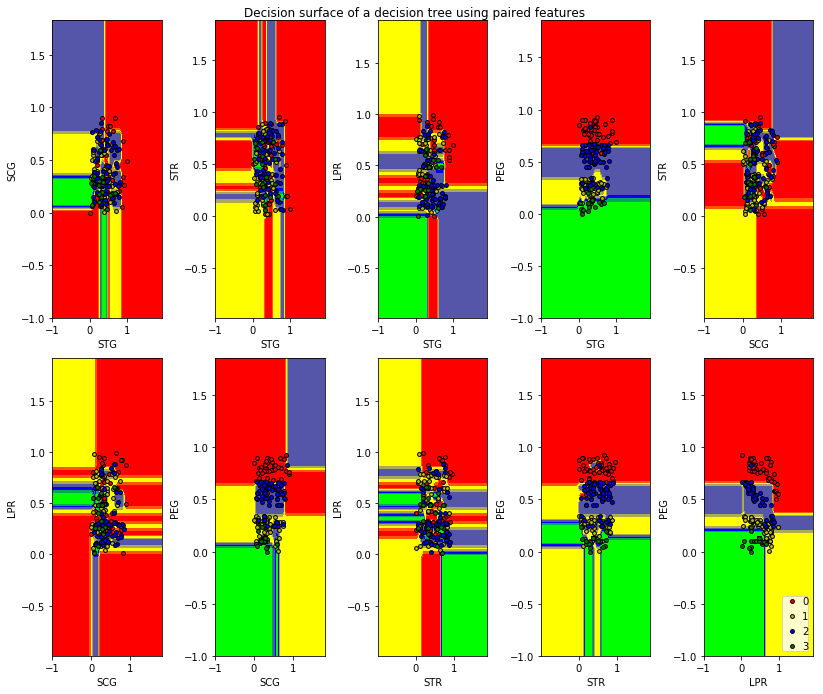

In [7]:
model = decision_boundary(dataBunch,train_x, train_y)

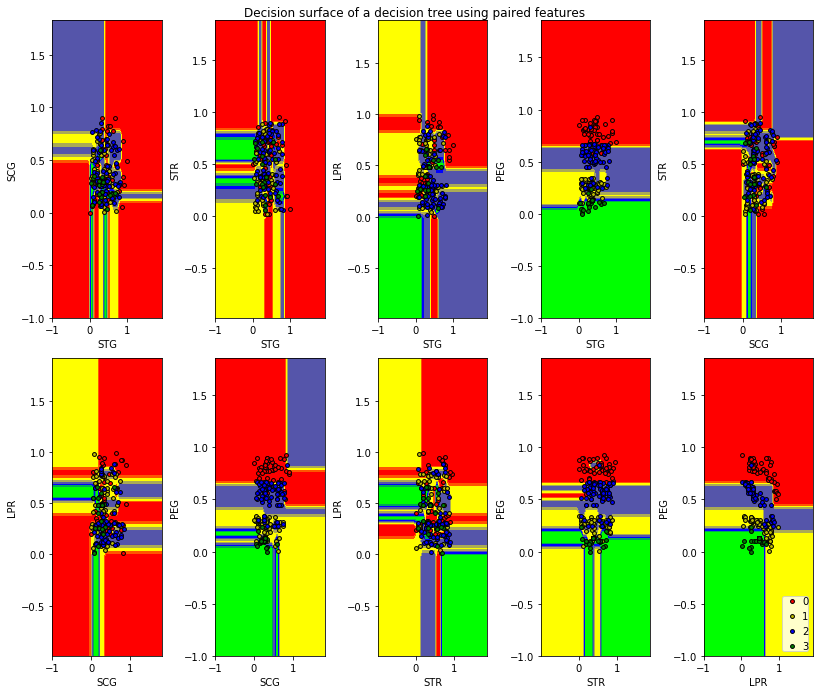

In [8]:
#Q5: use "decision_boundary" defined before. Use entropy as method. Pay attention to inputs


In [9]:
plt.figure(figsize = (12, 10))
clf = tree.DecisionTreeClassifier().fit(train_x, train_y)
tree.plot_tree(clf, filled=True)
plt.show()

AttributeError: module 'sklearn.tree' has no attribute 'plot_tree'

<Figure size 864x720 with 0 Axes>

In [ ]:
#Q6: use "decision_boundary" defined before. Use gini as method. Pay attention to inputs.


In [ ]:
tree_model = tree.DecisionTreeClassifier().fit(train_x, train_y) #Tree training
print('The proportion of the points that are correctly classified is %f'%metrics.accuracy_score(test_y, tree_model.predict(test_x)))

In [ ]:
print('The depth of the tree is %i'%tree_model.get_depth())

In [ ]:
#Q7: print accuracy for depths of 1 to 10

